# 04_calibrate_thermal

This notebook shows how the thermal images were calibrated using the models generated in the previous notebook.

In [ ]:
import joblib
import numpy as np
import rasterio as rio
import subprocess
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="rasterio")

Retrieve the calibration model fitted for this flight.

In [ ]:
DATE = "20250807"

MODELS_DIR = "results/03_regression"
FLIGHT_DIR = "data/h20t/images"
OUT_DIR = f"results/04_calibrate_thermal"
os.makedirs(OUT_DIR, exist_ok=True)

#FLIGHT_DIRS = { #commented out as the rest is not in the demo
#    "20250622": f"{FLIGHT_DIR}/20250622/h20t/images",
#    "20250807": f"{FLIGHT_DIR}/20250807/h20t/images",
#    "20250813": f"{FLIGHT_DIR}/20250813/h20t/images",
#    "20250814": f"{FLIGHT_DIR}/20250814/h20t/images",
#}

EXIFTOOL = "tools/exiftool.exe"

In [ ]:
pkl_path = f"{MODELS_DIR}/model_{DATE}.pkl"

model = joblib.load(pkl_path)
a = float(model.coef_[0])     # slope
b = float(model.intercept_)   # interscept
print(f"T_cal = {a:.4f} × T_raw + {b:.3f}")

T_cal = 0.8164 × T_raw + 8.645


In [ ]:
# 20250622: T_cal = 1.0343 × T_raw + 1.166
# 20250807: T_cal = 0.8164 × T_raw + 8.645
# 20250813: T_cal = 0.9433 × T_raw + 8.390
# 20250814: T_cal = 1.0183 × T_raw + 2.131

In [ ]:
fnames = sorted([f for f in os.listdir(FLIGHT_DIR) if f.lower().endswith(".tiff")])
print(f"{len(fnames)} thermal images found in {FLIGHT_DIR}")

10 thermal images found in data/h20t/images


In [ ]:
demo_idx = len(fnames) // 2
fname_demo = fnames[demo_idx]
print(f"Sample image: {fname_demo}")

Sample image: DJI_20250807135729_0408_T.tiff


Calibrate the data with the model. The fitted linear transform (`T_cal = a·T_raw + b`) is applied to every pixel of each thermal frame and the result is written as a new GeoTIFF. The XMP and GPS tags are then copied from the originals with ExifTool, so the calibrated frames keep the positioning metadata that OpenDroneMap needs to align them during mosaicking.

In [ ]:
fnames = sorted([f for f in os.listdir(FLIGHT_DIR) if f.lower().endswith(".tiff")])

pkl_path = f"{MODELS_DIR}/model_{DATE}.pkl"
model = joblib.load(pkl_path)
a = float(model.coef_[0])
b = float(model.intercept_)

for i, fname in enumerate(fnames):
    img_path = f"{FLIGHT_DIR}/{fname}"
    out_path = f"{OUT_DIR}/{fname}"

    with rio.open(img_path) as src:
        img = src.read(1).astype("float32")
        profile = src.profile.copy()

    corrected = (b + a * img).astype("float32")

    profile.update(dtype="float32", compress="lzw")
    with rio.open(out_path, "w", **profile) as dst:
        dst.write(corrected, 1)

    subprocess.run([EXIFTOOL, "-tagsfromfile", str(img_path), str(out_path), "-xmp:all", "-gps:all", "-overwrite_original"], capture_output=True)

print(f"{DATE}: {len(fnames)} calibrated images written to {OUT_DIR}")

20250807: 10 calibrated images written to results/04_calibrate_thermal


Display the demo image before and after the calibration:

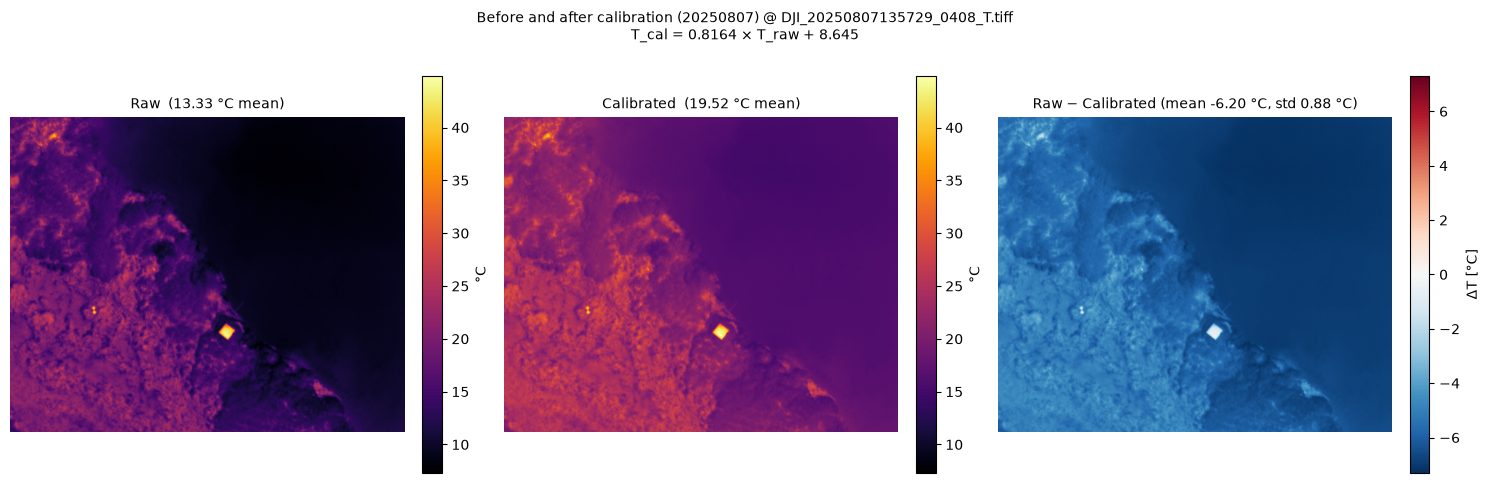

In [ ]:
orig_path = f"{FLIGHT_DIR}/{fname_demo}"
cal_path = f"{OUT_DIR}/{fname_demo}"

with rio.open(orig_path) as src:
    orig = src.read(1).astype("float32")
with rio.open(cal_path) as src:
    cal  = src.read(1).astype("float32")

diff = orig - cal

vmin_t = min(orig.min(), cal.min())
vmax_t = max(orig.max(), cal.max())
diff_abs = np.abs(diff).max()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(orig, cmap="inferno", vmin=vmin_t, vmax=vmax_t)
axes[0].set_title(f"Raw  ({orig.mean():.2f} °C mean)", fontsize=10)
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="°C")

im1 = axes[1].imshow(cal, cmap="inferno", vmin=vmin_t, vmax=vmax_t)
axes[1].set_title(f"Calibrated  ({cal.mean():.2f} °C mean)", fontsize=10)
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="°C")

im2 = axes[2].imshow(diff, cmap="RdBu_r", vmin=-diff_abs, vmax=diff_abs)
axes[2].set_title(
    f"Raw − Calibrated (mean {diff.mean():.2f} °C, std {diff.std():.2f} °C)", fontsize=10)
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label="ΔT [°C]")

fig.suptitle(f"Before and after calibration ({DATE}) @ {fname_demo}\n"
             f"T_cal = {a:.4f} × T_raw + {b:.3f}", fontsize=10)
fig.tight_layout()
plt.savefig(cal_path.replace(".tiff", "_calibration_effect.png"), dpi=200)

With every frame calibrated, the images are ready to be assembled into an orthomosaic in OpenDroneMap / WebODM (done outside this notebook).

## Calibrate everything (not to be executed)

In [ ]:
for d in ['20250622', '20250807', '20250813', '20250814']:
    root_dir = FLIGHT_DIRS[d]
    root_out = f"{root_dir}/calibrated"
    os.makedirs(root_out, exist_ok=True)

    pkl_path = f"{MODELS_DIR}/model_{d}.pkl"
    model = joblib.load(pkl_path)
    a = float(model.coef_[0])     # gain (slope)
    b = float(model.intercept_)   # offset (intercept)

    fnames = sorted([f for f in os.listdir(root_dir) if f.lower().endswith(".tiff")])
    for i, fname in enumerate(fnames):
        img_path = f"{root_dir}/{fname}"
        out_path = f"{root_out}/{fname}"

        with rio.open(img_path) as src:
            img = src.read(1).astype("float32")
            profile = src.profile.copy()

        corrected = (b + a * img).astype("float32")

        profile.update(dtype="float32", compress="lzw")
        with rio.open(out_path, "w", **profile) as dst:
            dst.write(corrected, 1)

        subprocess.run([EXIFTOOL, "-tagsfromfile", str(img_path), str(out_path), "-xmp:all", "-gps:all", "-overwrite_original"], capture_output=True)

    print(f"{d}:  {len(fnames)} calibrated images written to {root_out}")